In [1]:
# The way this tutorial uses the `TimeDistributed` layer requires TF>=2.10

%pip install -U "tensorflow>=2.10.0"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip install rarfile patool tqdm opencv-python
%pip install -q git+https://github.com/tensorflow/docs

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
%pip install imageio

import tqdm 
import random 
import pathlib 
import itertools 
import collections

import os 
import cv2 
import numpy as np 
import remotezip as rz 
import rarfile
import patoolib

import tensorflow as tf 

#some  modules to display an animation using imageio 
import imageio 
from IPython import display 
from urllib import request 
from tensorflow_docs.vis import embed




Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# Path to local RAR archive containing the UCF101 videos
ARCHIVE = 'ucf101.rar'


In [5]:
def list_files_from_rar(rar_path):
    """List the files in the RAR archive and return filenames."""
    files = []
    import rarfile
    with rarfile.RarFile(rar_path) as rf:
        for info in rf.infolist():
            files.append(info.filename)
    return files


In [6]:
files = list_files_from_rar(ARCHIVE)
files = [f for f in files if f.endswith('.avi')]
files[:10]

['UCF-101/ApplyEyeMakeup/v_ApplyEyeMakeup_g01_c01.avi',
 'UCF-101/ApplyEyeMakeup/v_ApplyEyeMakeup_g01_c02.avi',
 'UCF-101/ApplyEyeMakeup/v_ApplyEyeMakeup_g01_c03.avi',
 'UCF-101/ApplyEyeMakeup/v_ApplyEyeMakeup_g01_c04.avi',
 'UCF-101/ApplyEyeMakeup/v_ApplyEyeMakeup_g01_c05.avi',
 'UCF-101/ApplyEyeMakeup/v_ApplyEyeMakeup_g01_c06.avi',
 'UCF-101/ApplyEyeMakeup/v_ApplyEyeMakeup_g02_c01.avi',
 'UCF-101/ApplyEyeMakeup/v_ApplyEyeMakeup_g02_c02.avi',
 'UCF-101/ApplyEyeMakeup/v_ApplyEyeMakeup_g02_c03.avi',
 'UCF-101/ApplyEyeMakeup/v_ApplyEyeMakeup_g02_c04.avi']

In [7]:
def download_from_rar(rar_path, to_dir, file_names):
  """Extract specific files from a local RAR archive into `to_dir`."""
  # rarfile and pathlib are already imported in another cell
  with rarfile.RarFile(rar_path) as rf:
    for fn in tqdm.tqdm(file_names):
      class_name = get_class(fn)
      target_dir = to_dir / class_name
      target_dir.mkdir(parents=True, exist_ok=True)
      rf.extract(fn, path=str(target_dir))
      unzipped_file = target_dir / fn
      fn_name = pathlib.Path(fn).parts[-1]
      output_file = target_dir / fn_name
      if unzipped_file.exists():
        unzipped_file.rename(output_file)


def get_class(filepath):
  """Return the class name for a file path in the archive.

  Example: 'UCF-101/ApplyEyeMakeup/v_...avi' -> 'UCF-101' or if you want the
  actual action class (second component) return parts[1] instead.
  """
  parts = pathlib.Path(filepath).parts
  # If archive paths are like 'UCF-101/ApplyEyeMakeup/...' return the action class:
  return parts[1] if len(parts) > 1 else (parts[0] if parts else '')


def get_files_per_class(files):
  """Retrieve the files that belong to each class.

  Args:
    files: List of files in the dataset.

  Returns:
    Dictionary of class names (key) and files (values).
  """
  files_for_class = collections.defaultdict(list)
  for fname in files:
    class_name = get_class(fname)
    files_for_class[class_name].append(fname)
  return files_for_class


In [8]:
NUM_CLASSES = 10
FILES_PER_CLASS = 50


In [9]:
files_for_class = get_files_per_class(files) 
classes = list(files_for_class.keys())

In [10]:
print('Num Classes: ', len(classes)) 
print('Num videos for class[0]:', len(files_for_class[classes[0]]))

Num Classes:  101
Num videos for class[0]: 145


In [11]:
def select_subset_of_classes(files_for_class, classes, files_per_class):
  """ Create a dictionary with the class name and a subset of the files in that class.

    Args:
      files_for_class: Dictionary of class names (key) and files (values).
      classes: List of classes.
      files_per_class: Number of files per class of interest.

    Returns:
      Dictionary with class as key and list of specified number of video files in that class.
  """
  files_subset  = dict() 
  for class_name in classes: 
    class_files = files_for_class[class_name]
    files_subset[class_name] = class_files[:files_per_class]

    return files_subset

In [12]:
files_subset = select_subset_of_classes(files_for_class, classes[:NUM_CLASSES], FILES_PER_CLASS)
list(files_subset.keys())

['ApplyEyeMakeup']

In [13]:
def download_from_zip(zip_url, to_dir, file_names):
  """ Download the contents of the zip file from the zip URL.

    Args:
      zip_url: A URL with a zip file containing data.
      to_dir: A directory to download data to.
      file_names: Names of files to download.
  """
  with rz.RemoteZip(zip_url) as zip:
    for fn in tqdm.tqdm(file_names):
      class_name = get_class(fn)
      zip.extract(fn, str(to_dir / class_name))
      unzipped_file = to_dir / class_name / fn

      fn = pathlib.Path(fn).parts[-1]
      output_file = to_dir / class_name / fn
      unzipped_file.rename(output_file)


In [14]:
def split_class_lists(files_for_class, count):
  """ Returns the list of files belonging to a subset of data as well as the remainder of
    files that need to be downloaded.

    Args:
      files_for_class: Files belonging to a particular class of data.
      count: Number of files to download.

    Returns:
      Files belonging to the subset of data and dictionary of the remainder of files that need to be downloaded.
  """
  split_files = []
  remainder = {}
  for cls in files_for_class:
    split_files.extend(files_for_class[cls][:count])
    remainder[cls] = files_for_class[cls][count:]
  return split_files, remainder


In [15]:
def download_ucf_101_subset(archive_path, num_classes, splits, download_dir):
  """ Download a subset of the UCF101 dataset from a local archive and split them. """
  files = list_files_from_rar(archive_path)
  for f in list(files):
    path = os.path.normpath(f)
    tokens = path.split(os.sep)
    if len(tokens) <= 2:
      files.remove(f) # Remove that item from the list if it does not have a filename

  files_for_class = get_files_per_class(files)

  classes = list(files_for_class.keys())[:num_classes]

  for cls in classes:
    random.shuffle(files_for_class[cls])

  files_for_class = {x: files_for_class[x] for x in classes}

  dirs = {}
  for split_name, split_count in splits.items():
    print(split_name, ":")
    split_dir = download_dir / split_name
    split_files, files_for_class = split_class_lists(files_for_class, split_count)
    download_from_rar(archive_path, split_dir, split_files)
    dirs[split_name] = split_dir

  return dirs


In [16]:
%pip install unrar


download_dir = pathlib.Path('./UCF101_subset/')
subset_paths = download_ucf_101_subset(ARCHIVE,
                                       num_classes=NUM_CLASSES,
                                       splits={"train": 30, "val": 10, "test": 10},
                                       download_dir=download_dir)



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
train :


100%|██████████| 300/300 [00:13<00:00, 22.51it/s]


val :


100%|██████████| 100/100 [00:04<00:00, 23.43it/s]


test :


100%|██████████| 100/100 [00:04<00:00, 24.38it/s]


In [17]:
video_count_train = len(list(download_dir.glob('train/*/*.avi')))
video_count_val = len(list(download_dir.glob('val/*/*.avi')))
video_count_test = len(list(download_dir.glob('test/*/*.avi')))
video_total = video_count_train + video_count_val + video_count_test
print(f"Total videos: {video_total}")


Total videos: 500


In [18]:
def format_frames(frame, output_size):
  """
    Pad and resize an image from a video.

    Args:
      frame: Image that needs to resized and padded. 
      output_size: Pixel size of the output frame image.

    Return:
      Formatted frame with padding of specified output size.
  """
  frame = tf.image.convert_image_dtype(frame, tf.float32)
  frame = tf.image.resize_with_pad(frame, *output_size)
  return frame

In [19]:
def frames_from_video_file(video_path, n_frames, output_size = (224,224), frame_step = 15):
  """
    Creates frames from each video file present for each category.

    Args:
      video_path: File path to the video.
      n_frames: Number of frames to be created per video file.
      output_size: Pixel size of the output frame image.

    Return:
      An NumPy array of frames in the shape of (n_frames, height, width, channels).
  """
  # Read each video frame by frame
  result = []
  src = cv2.VideoCapture(str(video_path))  

  video_length = src.get(cv2.CAP_PROP_FRAME_COUNT)
  video_length = int(video_length)

  need_length = 1 + (n_frames - 1) * frame_step

  if need_length > video_length:
    start = 0
  else:
    max_start = video_length - need_length
    start = random.randint(0, max_start + 1)

  src.set(cv2.CAP_PROP_POS_FRAMES, start)
  # ret is a boolean indicating whether read was successful, frame is the image itself
  ret, frame = src.read()
  result.append(format_frames(frame, output_size))

  for _ in range(n_frames - 1):
    for _ in range(frame_step):
      ret, frame = src.read()
    if ret:
      frame = format_frames(frame, output_size)
      result.append(frame)
    else:
      result.append(np.zeros_like(result[0]))
  src.release()
  result = np.array(result)[..., [2, 1, 0]]

  return result


In [20]:
video_path = "End_of_a_jam.ogv"


In [21]:
!curl -O https://upload.wikimedia.org/wikipedia/commons/8/86/End_of_a_jam.ogv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0 55.0M    0 98304    0     0   149k      0  0:06:17 --:--:--  0:06:17  149k
  3 55.0M    3 2107k    0     0  1311k      0  0:00:43  0:00:01  0:00:42 1312k
  9 55.0M    9 5530k    0     0  2121k      0  0:00:26  0:00:02  0:00:24 2122k
 15 55.0M   15 8923k    0     0  2474k      0  0:00:22  0:00:03  0:00:19 2474k
 21 55.0M   21 12.0M    0     0  2680k      0  0:00:21  0:00:04  0:00:17 2680k
 27 55.0M   27 15.4M    0     0  2813k      0  0:00:20  0:00:05  0:00:15 3157k
 34 55.0M   34 18.7M    0     0  2906k      0  0:00:19  0:00:06  0:00:13 3418k
 40 55.0M   40 22.0M    0     0  2974k      0  0:00:18  0:00:07  0:00:11 3418k
 46 55.0M   46 25.4M    0     0  3024k      0  0:00:18  0:00:08  0:00:10 3421k
 52 55.0M   52 28.7M    0     0  3065k      0  0:00

In [22]:
sample_video = frames_from_video_file(video_path, n_frames = 10)
sample_video.shape

(10, 224, 224, 3)

In [23]:
def to_gif(images): 
    converted_images = np.clip(images * 255, 0, 255).astype(np.uint8)
    imageio.mimsave('./animation.gif', converted_images, fps=10)
    return embed.embed_file('./animation.gif')


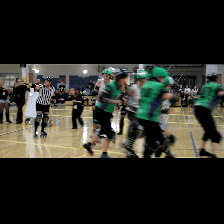

In [24]:
to_gif(sample_video)

In [25]:
class FrameGenerator:
  def __init__(self, path, n_frames, training = False):
    """ Returns a set of frames with their associated label. 

      Args:
        path: Video file paths.
        n_frames: Number of frames. 
        training: Boolean to determine if training dataset is being created.
    """
    self.path = path
    self.n_frames = n_frames
    self.training = training
    self.class_names = sorted(set(p.name for p in self.path.iterdir() if p.is_dir()))
    self.class_ids_for_name = dict((name, idx) for idx, name in enumerate(self.class_names))

  def get_files_and_class_names(self):
    video_paths = list(self.path.glob('*/*.avi'))
    classes = [p.parent.name for p in video_paths] 
    return video_paths, classes

  def __call__(self):
    video_paths, classes = self.get_files_and_class_names()

    pairs = list(zip(video_paths, classes))

    if self.training:
      random.shuffle(pairs)

    for path, name in pairs:
      video_frames = frames_from_video_file(path, self.n_frames) 
      label = self.class_ids_for_name[name] # Encode labels
      yield video_frames, label


In [26]:
fg = FrameGenerator(subset_paths['train'], 10, training=True)

frames, label = next(fg())

print(f"shape : {frames.shape}")
print(f"Label: {label}")

shape : (10, 224, 224, 3)
Label: 5


In [27]:

# Debug: Check if class_ids_for_name is populated
print("Class names:", fg.class_names)
print("Class IDs for name:", fg.class_ids_for_name)
print("Label value:", label)
print("Label type:", type(label))

Class names: ['ApplyEyeMakeup', 'ApplyLipstick', 'Archery', 'BabyCrawling', 'BalanceBeam', 'BandMarching', 'BaseballPitch', 'Basketball', 'BasketballDunk', 'BenchPress']
Class IDs for name: {'ApplyEyeMakeup': 0, 'ApplyLipstick': 1, 'Archery': 2, 'BabyCrawling': 3, 'BalanceBeam': 4, 'BandMarching': 5, 'BaseballPitch': 6, 'Basketball': 7, 'BasketballDunk': 8, 'BenchPress': 9}
Label value: 5
Label type: <class 'int'>


In [28]:
# Create the training set
output_signature = (tf.TensorSpec(shape = (None, None, None, 3), dtype = tf.float32),
                    tf.TensorSpec(shape = (), dtype = tf.int16))
train_ds = tf.data.Dataset.from_generator(FrameGenerator(subset_paths['train'], 10, training=True),
                                          output_signature = output_signature)

In [29]:
for frames, labels in train_ds.take(10):
  print(labels)


tf.Tensor(5, shape=(), dtype=int16)
tf.Tensor(1, shape=(), dtype=int16)
tf.Tensor(9, shape=(), dtype=int16)
tf.Tensor(3, shape=(), dtype=int16)
tf.Tensor(8, shape=(), dtype=int16)
tf.Tensor(0, shape=(), dtype=int16)
tf.Tensor(4, shape=(), dtype=int16)
tf.Tensor(5, shape=(), dtype=int16)
tf.Tensor(5, shape=(), dtype=int16)
tf.Tensor(9, shape=(), dtype=int16)


In [30]:
# Create validation dataset
val_ds = tf.data.Dataset.from_generator(FrameGenerator(subset_paths['val'], 10),
                                        output_signature = output_signature)

In [31]:
# Create the validation set
val_ds = tf.data.Dataset.from_generator(FrameGenerator(subset_paths['val'], 10),
                                        output_signature = output_signature)


In [32]:
# Print the shapes of the data
train_frames, train_labels = next(iter(train_ds))
print(f'Shape of training set of frames: {train_frames.shape}')
print(f'Shape of training labels: {train_labels.shape}')

val_frames, val_labels = next(iter(val_ds))
print(f'Shape of validation set of frames: {val_frames.shape}')
print(f'Shape of validation labels: {val_labels.shape}')


Shape of training set of frames: (10, 224, 224, 3)
Shape of training labels: ()
Shape of validation set of frames: (10, 224, 224, 3)
Shape of validation labels: ()


In [33]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size= AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)

In [34]:
train_ds = train_ds.batch(2) 
val_ds = val_ds.batch(2) 


train_frames, train_labels = next(iter(train_ds))
print(f'Shape of training set of frames: {train_frames.shape}')
print(f'Shape of training labels: {train_labels.shape}')

val_frames, val_labels = next(iter(val_ds))
print(f'Shape of validation set of frames: {val_frames.shape}')
print(f'Shape of validation labels: {val_labels.shape}')

Shape of training set of frames: (2, 10, 224, 224, 3)
Shape of training labels: (2,)
Shape of validation set of frames: (2, 10, 224, 224, 3)
Shape of validation labels: (2,)


In [36]:
net = tf.keras.applications.EfficientNetB0(input_shape=(224, 224, 3), include_top=False, weights=None)
net.trainable = False 

model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(scale=255), 
    tf.keras.layers.TimeDistributed(net), 
    tf.keras.layers.Dense(10), 
    tf.keras.layers.GlobalAveragePooling3D()
])


model.compile(
    optimizer='adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits= True), 
    metrics = ['accuracy']
)

model.fit(train_ds, epochs= 10, validation_data = val_ds, callbacks = tf.keras.callbacks.EarlyStopping(patience= 2, monitor= 'val_loss'))

Epoch 1/10
    150/Unknown 49s 247ms/step - accuracy: 0.1120 - loss: 2.3029

e:\programs\py\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


150/150 ━━━━━━━━━━━━━━━━━━━━ 64s 348ms/step - accuracy: 0.0800 - loss: 2.3038 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 2/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 48s 319ms/step - accuracy: 0.0767 - loss: 2.3035 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 3/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 46s 308ms/step - accuracy: 0.0800 - loss: 2.3035 - val_accuracy: 0.1000 - val_loss: 2.3025
Epoch 4/10
137/150 ━━━━━━━━━━━━━━━━━━━━ 3s 241ms/step - accuracy: 0.0972 - loss: 2.3031

KeyboardInterrupt: 